In [ ]:
!pip install rasterio

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dholavira.jpg to Dholavira.jpg
Saving Hampi.jpg to Hampi.jpg
Saving Hampi1.jpg to Hampi1.jpg
Saving Hampi2.jpg to Hampi2.jpg
Saving Hampi3.jpg to Hampi3.jpg
Saving hampi4.jpg to hampi4.jpg
Saving output_37_b.png to output_37_b.png
Saving output_38_23.png to output_38_23.png
Saving output_41_30.png to output_41_30.png
Saving output_42_29.png to output_42_29.png
Saving output_42_b.png to output_42_b.png
Saving output_44_35.png to output_44_35.png
Saving output_45_23.png to output_45_23.png
Saving output_46_42.png to output_46_42.png
Saving output_47_27.png to output_47_27.png
Saving output_54_43.png to output_54_43.png
Saving output_55_1_b.png to output_55_1_b.png
Saving output_55_b.png to output_55_b.png
Saving output_57_b.png to output_57_b.png
Saving output_58_28.png to output_58_28.png
Saving output_59_20.png to output_59_20.png
Saving output_60_25.png to output_60_25.png
Saving output_61_b.png to output_61_b.png
Saving output_64_b.png to output_64_b.png
Saving output_123_28.p

In [ ]:
import cv2
import numpy as np
import pandas as pd
import random

In [ ]:
all_features = []

for filename in uploaded.keys():

    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize for speed
    img = cv2.resize(img, (256, 256))

    red = img[:,:,0].astype(float)
    green = img[:,:,1].astype(float)

    # NDVI
    ndvi = (green - red) / (green + red + 1e-5)

    # Slope
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(float)
    dx, dy = np.gradient(gray)
    slope = np.sqrt(dx**2 + dy**2)

    # Elevation
    elevation = gray

    h, w = gray.shape

    for i in range(h):
        for j in range(w):
            all_features.append([
                slope[i][j],
                ndvi[i][j],
                elevation[i][j]
            ])

In [ ]:
sample_size = 200000  # 2 lakh rows (perfect size)

if len(all_features) > sample_size:
    all_features = random.sample(all_features, sample_size)

In [ ]:
df = pd.DataFrame(all_features, columns=["slope", "ndvi", "elevation"])

In [ ]:
def label_data(slope, ndvi):
    if slope > 20 and ndvi < 0.2:
        return 1  # erosion-prone
    else:
        return 0  # stable

df["label"] = [label_data(s, n) for s, n in zip(df["slope"], df["ndvi"])]

In [ ]:
print(df.head())

print("\nClass Distribution:")
print(df["label"].value_counts())

       slope      ndvi  elevation  label
0  28.151377  0.000000       71.0      1
1  11.401754  0.070111      140.0      0
2   6.519202 -0.089918      172.0      0
3  11.853270 -0.149321      103.0      0
4   6.946222 -0.121622      138.0      0

Class Distribution:
label
0    154318
1     45682
Name: count, dtype: int64


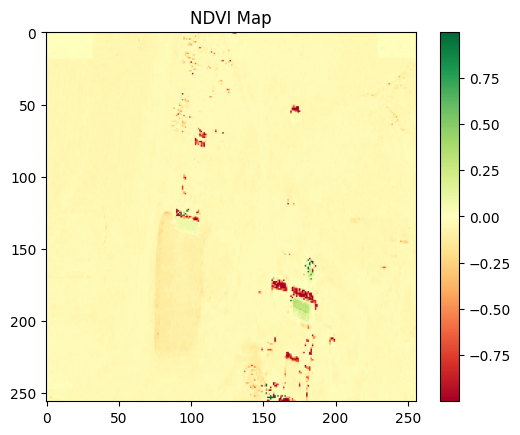

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(ndvi, cmap='RdYlGn')
plt.title("NDVI Map")
plt.colorbar()
plt.show()

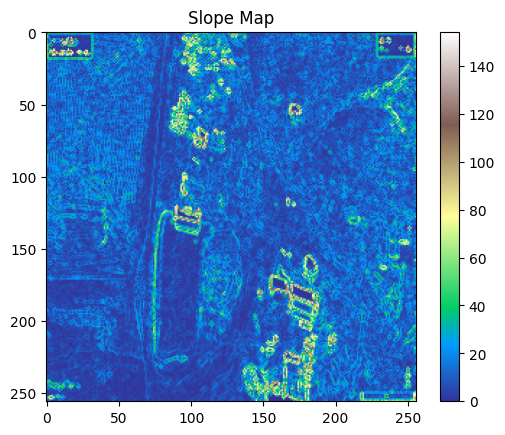

In [ ]:
plt.imshow(slope, cmap='terrain')
plt.title("Slope Map")
plt.colorbar()
plt.show()

In [ ]:
df.to_csv("erosion_dataset.csv", index=False)

In [ ]:
from google.colab import files
files.download("erosion_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>